In [1]:
from sentence_transformers import SentenceTransformer
import tqdm as notebook_tqdm
import torch
from tqdm import tqdm
# Load the embedding model
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
print("Model loaded!")

/home/tom/bre-fine-arts/Fine-Arts-Main/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 310/310 [00:00<00:00, 4363.86it/s]


Model loaded!


In [2]:
# Import required libraries for image downloading and display
import requests
from requests.auth import HTTPBasicAuth
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display
import os
from dotenv import load_dotenv
load_dotenv()

# Nextcloud configuration
NC_HOST = os.getenv("DB_HOST")
NC_ACC = os.getenv("NC_ACC")
NC_PASS = os.getenv("NC_PASS")

print(f"Nextcloud host: {NC_HOST}")
print(f"Nextcloud account: {NC_ACC}")

Nextcloud host: 192.168.0.150
Nextcloud account: Tom


In [3]:
def get_images(file_id, file_path):
    """
    Download and display a thumbnail/preview for a file from Nextcloud.
    
    Args:
        file_id: The Nextcloud file ID
        file_path: The path to the file on the Nextcloud server
    
    Returns:
        PIL.Image: The resized 256x256 PIL Image
    """
    server_url = f'http://{NC_HOST}:8080/remote.php/dav/files/{NC_ACC}'
    preview_url = f'http://{NC_HOST}:8080/core/preview?fileId={file_id}&x=1080&y=1080'
    username = NC_ACC
    password = NC_PASS

    file_url = f"{server_url}{file_path}"

    response = requests.get(preview_url, auth=HTTPBasicAuth(username, password), stream=True)
 
    if response.status_code == 200:
        file_in_memory = BytesIO()
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                file_in_memory.write(chunk)
        file_in_memory.seek(0)
        img = PILImage.open(file_in_memory)
        img = img.resize((256, 256))
        display(img)
    elif response.status_code == 404:
        try:
            response = requests.get(file_url, auth=HTTPBasicAuth(username, password), stream=True)
            file_in_memory = BytesIO()
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file_in_memory.write(chunk)
            file_in_memory.seek(0)
            source_img = PILImage.open(file_in_memory)
            img_display = source_img.resize((256, 256))
            display(img_display)
        except Exception as e:
            print(f"Failed to download file. Exception: {e}")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")
    
    try:
        import gc
        del file_in_memory
        gc.collect()
    except:
        pass
    return img

In [4]:
from sqlalchemy import create_engine, MetaData, Table, select, insert
from sqlalchemy.exc import SQLAlchemyError
import pandas as pd

def create_db_connection():
    load_dotenv()
    DB_HOST = os.getenv("DB_HOST")
    DB_NAME = os.getenv("DB_NAME")
    DB_USER = os.getenv("DB_USER")
    DB_PASSWORD = os.getenv("DB_PASSWORD")
    engine = create_engine('postgresql+pg8000://'+DB_USER+':'+DB_PASSWORD+'@'+DB_HOST+':5432/'+DB_NAME)
    return engine

def get_tags():
    try:
        engine = create_db_connection()
        df_systag = pd.read_sql_table('oc_systemtag', engine)
        df_tagmap = pd.read_sql_table('oc_systemtag_object_mapping', engine)
    except SQLAlchemyError as e:
        print(f"An error occurred: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    return df_systag, df_tagmap

In [5]:
print("Loading tags from database...")
df_systag, df_tagmap = get_tags()
print(f"Loaded {len(df_systag)} tags and {len(df_tagmap)} mappings")

Loading tags from database...
Loaded 766 tags and 21533 mappings


In [6]:
# ============================================
# Document Aggregation Approach
# ============================================
# Build a document for each file by aggregating all its tags.
# This creates a richer semantic representation per file.

def build_file_documents(df_systag, df_tagmap):
    """
    Build a dictionary mapping file IDs to their aggregated tag documents.
    
    Args:
        df_systag: DataFrame with tag id and name columns
        df_tagmap: DataFrame with systemtagid and objectid columns
    
    Returns:
        dict: {file_id: "tag1 tag2 tag3 ..."}
    """
    # Merge tagmap with tag names
    tagmap_with_names = df_tagmap.merge(
        df_systag[['id', 'name']],
        left_on='systemtagid',
        right_on='id',
        how='inner'
    )
    
    # Group by file_id (objectid) and aggregate tag names
    file_docs = {}
    for file_id, group in tagmap_with_names.groupby('objectid'):
        # Sort tags alphabetically for consistency, deduplicate
        tags = sorted(set(group['name'].tolist()))
        file_docs[str(file_id)] = ' '.join(tags)
    
    return file_docs, tagmap_with_names

file_documents, tagmap_with_names = build_file_documents(df_systag, df_tagmap)
print(f"Built {len(file_documents)} file documents")

# Show some examples
print("\nExample file documents:")
for i, (file_id, doc) in enumerate(list(file_documents.items())[:5]):
    print(f"  File {file_id}: '{doc}'")

Built 1517 file documents

Example file documents:
  File 1000: 'abstract design element eye graphic icon iconography illustration minimalist modern orange red simplistic symbol visual'
  File 10001: 'botanical design digital floral graphic green greenish illustration inspire leaflike leave nature plant tropical'
  File 10017: 'abstract circle colorful composition contemporary form geometric minimalist modern semi shape'
  File 1003: 'background design evil eye folk graphic icon minimalist modern mystery mystic symbol symbolism yellow'
  File 10035: 'abstract artistic blue botanical composition digital floral geometric green inspire minimalist modern nature pattern teal textured'


In [7]:
# ============================================
# TF-IDF Weighted Document Embeddings
# ============================================
# Apply TF-IDF weighting to tags so rare/discriminative tags
# contribute more to the embedding than common tags.

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("Applying TF-IDF weighting to documents...")

# Get document texts in consistent order
doc_ids = list(file_documents.keys())
doc_texts = [file_documents[fid] for fid in doc_ids]

# Fit TF-IDF vectorizer on all documents
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
tfidf_matrix = tfidf_vectorizer.fit_transform(doc_texts)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

# Convert TF-IDF weighted sparse matrix back to dense text
# by repeating tags proportional to their TF-IDF scores
def tfidf_weighted_docs(tfidf_matrix, doc_ids, doc_texts, repeat_factor=3):
    """
    Create weighted document strings by repeating tags based on TF-IDF scores.
    
    Args:
        tfidf_matrix: Sparse TF-IDF matrix (n_docs x n_terms)
        doc_ids: List of document IDs
        doc_texts: List of original document texts
        repeat_factor: Maximum repeats for high-scoring terms
    
    Returns:
        list: Weighted document strings
    """
    vocabulary = tfidf_vectorizer.vocabulary_
    inv_vocab = {v: k for k, v in vocabulary.items()}
    
    weighted_docs = []
    for i in range(tfidf_matrix.shape[0]):
        row = tfidf_matrix.getrow(i)
        indices = row.nonzero()[1]
        scores = row.data
        
        # Sort by TF-IDF score descending
        sorted_order = np.argsort(scores)[::-1]
        indices = indices[sorted_order]
        scores = scores[sorted_order]
        
        # Repeat tags based on score (higher score = more repeats)
        weighted_tags = []
        for idx, score in zip(indices, scores):
            tag = inv_vocab[idx]
            # Scale repeats: min 1, max repeat_factor based on score
            repeats = max(1, int(score * repeat_factor))
            weighted_tags.extend([tag] * repeats)
        
        weighted_docs.append(' '.join(weighted_tags))
    
    return weighted_docs

# Create weighted documents (repeat_factor=3 means top tags repeat ~3x)
weighted_doc_texts = tfidf_weighted_docs(tfidf_matrix, doc_ids, doc_texts, repeat_factor=3)

# Show comparison
print("\nOriginal vs TF-IDF Weighted Documents:")
for i in range(min(5, len(doc_ids))):
    print(f"\n  File {doc_ids[i]}:")
    print(f"    Original:   '{doc_texts[i][:100]}...'")
    print(f"    Weighted:   '{weighted_doc_texts[i][:100]}...'")

Applying TF-IDF weighting to documents...
TF-IDF matrix shape: (1517, 766)
Vocabulary size: 766

Original vs TF-IDF Weighted Documents:

  File 1000:
    Original:   'abstract design element eye graphic icon iconography illustration minimalist modern orange red simpl...'
    Weighted:   'element iconography icon eye symbol simplistic graphic visual illustration red orange minimalist des...'

  File 10001:
    Original:   'botanical design digital floral graphic green greenish illustration inspire leaflike leave nature pl...'
    Weighted:   'leaflike greenish plant tropical inspire graphic digital leave illustration botanical floral green n...'

  File 10017:
    Original:   'abstract circle colorful composition contemporary form geometric minimalist modern semi shape...'
    Weighted:   'semi semi form circle contemporary shape minimalist geometric colorful modern composition abstract...'

  File 1003:
    Original:   'background design evil eye folk graphic icon minimalist modern mys

In [8]:
# ============================================
# Pre-compute TF-IDF Weighted Document Embeddings
# ============================================

print("Encoding TF-IDF weighted documents...")
tfidf_doc_embeddings = model.encode(weighted_doc_texts)
print(f"Encoded {len(tfidf_doc_embeddings)} weighted documents")
print(f"Embedding shape: {tfidf_doc_embeddings.shape}")

Encoding TF-IDF weighted documents...
Encoded 1517 weighted documents
Embedding shape: (1517, 1024)


In [9]:
# ============================================
# TF-IDF Weighted Document Similarity Search
# ============================================

def search_files_by_tfidf_document_similarity(query, top_k=10):
    """
    Search for files using TF-IDF weighted document embeddings.
    
    Args:
        query: Natural language search query
        top_k: Number of top results to return
    
    Returns:
        DataFrame with file_id, document, similarity score, ranked
    """
    # Encode the query
    query_embedding = model.encode(query, prompt_name="query")
    
    # Compute cosine similarity between query and all weighted document embeddings
    similarity = model.similarity(
        torch.tensor(query_embedding).unsqueeze(0),
        torch.tensor(tfidf_doc_embeddings)
    )
    
    # Get top-k indices
    top_indices = similarity[0].argsort(descending=True)[:top_k]
    
    # Build results DataFrame
    results = pd.DataFrame({
        'file_id': [doc_ids[i] for i in top_indices],
        'document': [doc_texts[i] for i in top_indices],
        'weighted_document': [weighted_doc_texts[i] for i in top_indices],
        'similarity': similarity[0][top_indices].cpu().numpy()
    })
    
    return results

print("TF-IDF weighted search function ready!")

TF-IDF weighted search function ready!


In [10]:
# ============================================
# Display Thumbnails for Search Results
# ============================================

def display_doc_search_thumbnails(results, top_n):
    """
    Display thumbnails for the top N files from document search results.
    
    Args:
        results: DataFrame with file_id column
        top_n: Number of thumbnails to display (default 3)
    """
    if results.empty:
        print("No files found.")
        return
    
    print(f"\nDisplaying top {min(top_n, len(results))} thumbnails:")
    for i, row in results.head(top_n).iterrows():
        file_id = row['file_id']
        print(f"Thumbnail {i+1}: File ID = {file_id}, Similarity = {row['similarity']:.4f}")
        file_path = "/images/"
        try:
            img = get_images(file_id, file_path)
        except Exception as e:
            print(f"  Failed to load image: {e}")
        print()

  0%|          | 0/3 [00:00<?, ?it/s]


Query: 'A painting with green landscape scene'

Top 10 results:
file_id                                                                                                                                     document  similarity
   6160               abstract artistic colorful composition earth green impasto impressionism impressionist landscape nature painting textured tone    0.605888
   5331   abstract artistic blurred calm contemporary green impressionism landscape minimalist modern nature organic painting smooth soft watercolor    0.603984
  10458    abstract blue colorful composition flower foliage green impressionism impressionist landscape leave nature painting tree water watercolor    0.603554
   5192                                   abstract artistic artwork blue colorful green impressionist landscape modern nature orange painting yellow    0.598835
   3436 abstract blue botanical composition floral flower garden grass green impressionism landscape nature painting plant sky wat

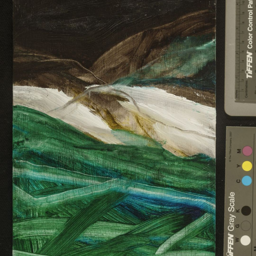


Thumbnail 2: File ID = 5331, Similarity = 0.6040


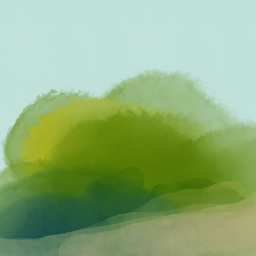


Thumbnail 3: File ID = 10458, Similarity = 0.6036


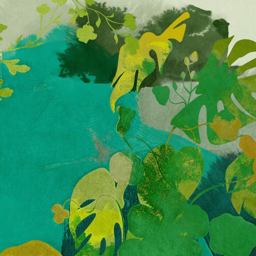

 33%|███▎      | 1/3 [00:02<00:04,  2.25s/it]



Query: 'portrait of a person'

Top 10 results:
file_id                                                                                                                                      document  similarity
   4027                        abstract black contemporary dramatic emotional expressive figure floral nature pink portrait red soft surrealism white    0.437001
   5171                   abstract artwork colorful contemporary figure flower green hat impressionism orange painting pink portrait red woman yellow    0.422669
    656                       abstract artwork colorful contemporary design figure geometric human minimalist modern pink purple red shape silhouette    0.360647
   7377                            abstract artwork blue colorful design digital floral green illustration nature orange pattern portrait red vibrant    0.350457
    854                                 abstract composition folk fruit graphic grid illustration life minimalist orange pattern red simplist

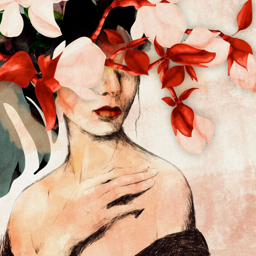


Thumbnail 2: File ID = 5171, Similarity = 0.4227


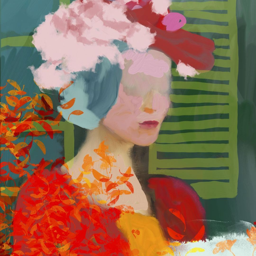


Thumbnail 3: File ID = 656, Similarity = 0.3606


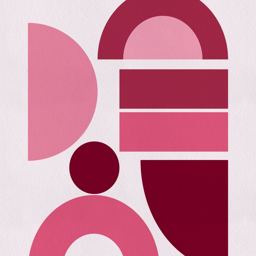

 67%|██████▋   | 2/3 [00:04<00:02,  2.22s/it]



Query: 'abstract art with bright colors'

Top 10 results:
file_id                                                                                                                                document  similarity
   1298                                                                             abstract artwork colorful design minimalist modern painting    0.647140
    804                                                                             abstract artwork colorful design minimalist modern painting    0.647140
   1269                                                                             abstract artwork colorful design minimalist modern painting    0.647140
    620 abstract abstractart artistic artstyle colorfield colorful contemporary fineart minimalist modern painting vibrant visualart watercolor    0.643243
   5418                                                                       abstract colorful composition contemporary design modern painting    0.640055
   7

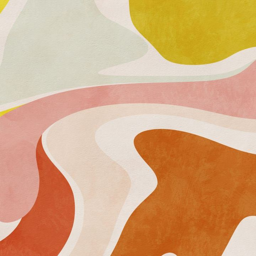


Thumbnail 2: File ID = 804, Similarity = 0.6471


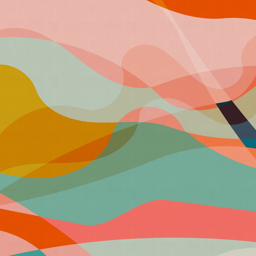


Thumbnail 3: File ID = 1269, Similarity = 0.6471


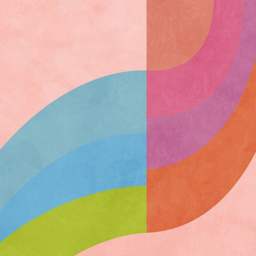

100%|██████████| 3/3 [00:06<00:00,  2.20s/it]

In [11]:
# ============================================
# Run TF-IDF Weighted Document Search Tests
# ============================================

test_queries = [
    "A painting with green landscape scene",
    "portrait of a person",
    "abstract art with bright colors",
]

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using TF-IDF weighted document similarity
    results = search_files_by_tfidf_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results[['file_id', 'document', 'similarity']].to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=3)

  0%|          | 0/3 [00:00<?, ?it/s]


Query: 'coloful contemproary art for a wallpaper'

Top 10 results:
file_id                                                                                                                                 document  similarity
   9804                       abstract artwork circle colorful cool decor design earthy geometric modern pattern textured vibrant wallpaper warm    0.575383
   7043            abstract artistic circle colorful composition decor decorative design geometric home modern pattern textile vibrant wallpaper    0.567522
   7938                                abstract circle colorful composition decor design geometric home modern pattern textile vibrant wallpaper    0.561056
   7760 abstract artistic circle colorful composition decor decorative design geometric home minimalist modern pattern textile vibrant wallpaper    0.560418
   9657                           abstract collage colorful composition decor design geometric home minimalist modern pattern shape textile wall   

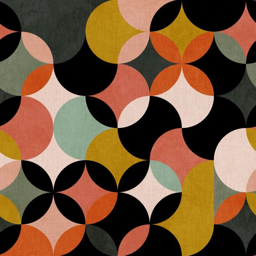


Thumbnail 2: File ID = 7043, Similarity = 0.5675


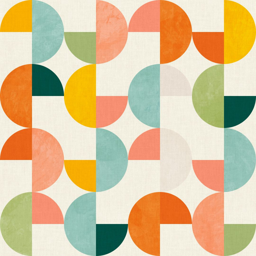


Thumbnail 3: File ID = 7938, Similarity = 0.5611


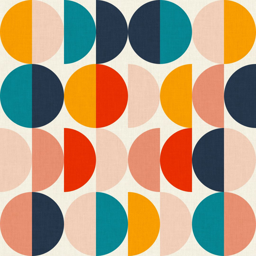


Thumbnail 4: File ID = 7760, Similarity = 0.5604


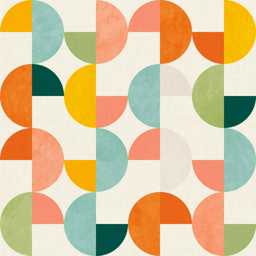


Thumbnail 5: File ID = 9657, Similarity = 0.5581


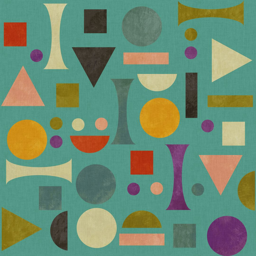

 33%|███▎      | 1/3 [00:03<00:06,  3.45s/it]



Query: 'greek villages'

Top 10 results:
file_id                                                                                                                                           document  similarity
   3844 architecture blue building cloud coastal greece house landscape mediterranean mountain nature painting residential scenic seaside sky street white    0.369986
    934            architecture building cityscape colorful community composition drawing house housing illustration minimalist pastel rural urban village    0.367819
    884    architecture building cartoon cityscape colorful composition design drawing flat home house illustration minimalist pastel simple urban village    0.331286
   1408                     architecture building cityscape composition design drawing home house illustration pattern residential structure urban village    0.328671
    867                  architecture blue building dome flower greek mediterranean minimalist modern nature santorini sea

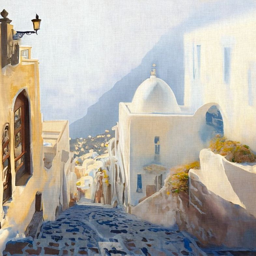


Thumbnail 2: File ID = 934, Similarity = 0.3678


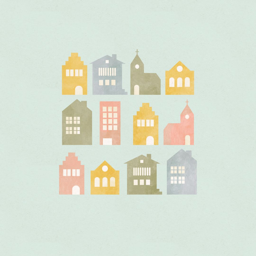


Thumbnail 3: File ID = 884, Similarity = 0.3313


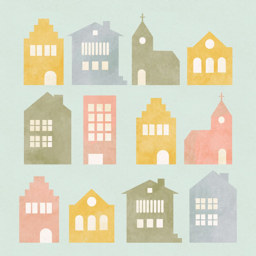


Thumbnail 4: File ID = 1408, Similarity = 0.3287


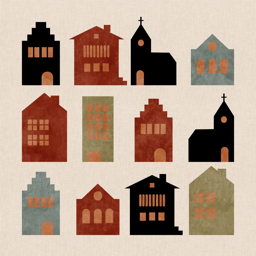


Thumbnail 5: File ID = 867, Similarity = 0.3286


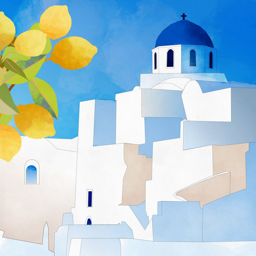

 67%|██████▋   | 2/3 [00:06<00:03,  3.37s/it]



Query: 'primarily green wallpaper patterns which are repetitive with flowers'

Top 10 results:
file_id                                                                                                                       document  similarity
   5442            abstract botanical colorful decor design fabric floral green home inspire interior nature pattern textile wallpaper    0.691137
  10162                  abstract botanical colorful design floral foliage green leave nature pattern pink repetitive symmetry vibrant    0.662714
  11026                botanical colorful decor design floral green home inspire interior leave nature organic pattern plant wallpaper    0.660685
   5456               abstract composition decor forest geometric green minimalist modern nature pattern repetition symmetry tree wall    0.659382
   6973     abstract botanical colorful composition design floral geometric green modern nature pattern red repetition symmetry yellow    0.655613
  10445 abstract blue

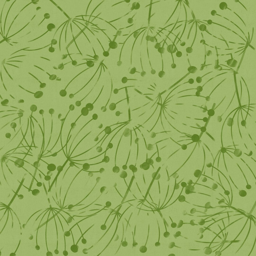


Thumbnail 2: File ID = 10162, Similarity = 0.6627


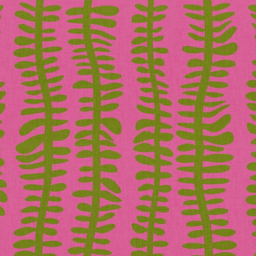


Thumbnail 3: File ID = 11026, Similarity = 0.6607


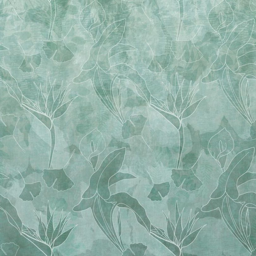


Thumbnail 4: File ID = 5456, Similarity = 0.6594


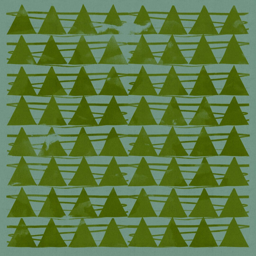


Thumbnail 5: File ID = 6973, Similarity = 0.6556


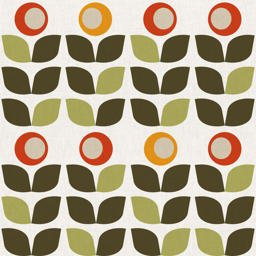

100%|██████████| 3/3 [00:10<00:00,  3.38s/it]

In [12]:
# ============================================
# Run TF-IDF Weighted Document Search Tests
# ============================================
test_queries = [
    "coloful contemproary art for a wallpaper",
    "greek villages",
    "primarily green wallpaper patterns which are repetitive with flowers",
]

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using TF-IDF weighted document similarity
    results = search_files_by_tfidf_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results[['file_id', 'document', 'similarity']].to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=5)

  0%|          | 0/1 [00:00<?, ?it/s]


Query: 'show me lemmons!'

Top 10 results:
file_id                                                                                                                            document  similarity
    732                   abstract black citrus food fruit geometric lemons life minimalist modern nature orange pattern still white yellow    0.461220
   1178                  abstract citrus foliage food fruit geometric green lemons life minimalist nature orange shape still texture yellow    0.400083
   3653                    bloom blossom branch delicate floral fruit green lemons life nature spring still vibrant watercolor white yellow    0.394652
    761       abstract black citrus design floral fruit geometric illustration lemons life nature orange pattern still textile white yellow    0.385650
    985                 abstract citrus composition design fruit graphic green lemons life minimalist modern orange silhouette still yellow    0.379184
   7468 abstract black citrus colorful flora

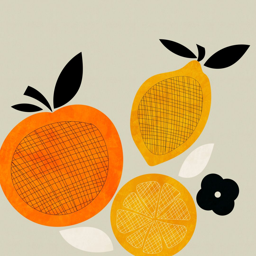


Thumbnail 2: File ID = 1178, Similarity = 0.4001


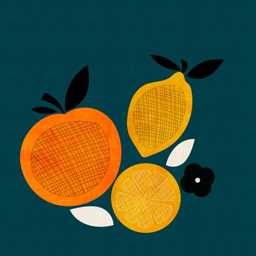


Thumbnail 3: File ID = 3653, Similarity = 0.3947


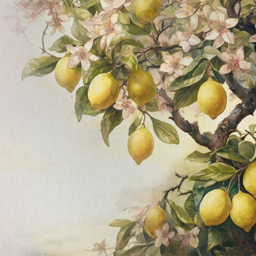


Thumbnail 4: File ID = 761, Similarity = 0.3857


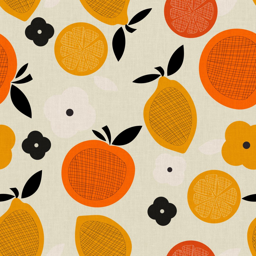


Thumbnail 5: File ID = 985, Similarity = 0.3792


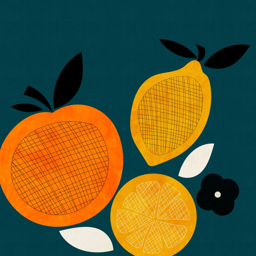

100%|██████████| 1/1 [00:03<00:00,  3.37s/it]

In [13]:
# ============================================
# Run TF-IDF Weighted Document Search Tests
# ============================================
test_queries = [
    "show me lemmons!",
]

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using TF-IDF weighted document similarity
    results = search_files_by_tfidf_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results[['file_id', 'document', 'similarity']].to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=5)